# <center> **RL Эксперименты с кастомной средой**

## <center> **1. Введение**

В рамках проекта рассматривается задача обучения агента с подкреплением в визуальной игровой среде **HeliRescue**, созданной на основе 2D‑игры на Pygame с управляемым вертолетом, падающим парашютистом и вражеским объектом alien. Агенту предоставляется доступ только к пиксельному представлению текущего кадра, а управление осуществляется через дискретный набор действий, имитирующих нажатия клавиш направления в исходной игре.

<img src="ScreenShots/screen1.png" alt="Game ScreenShot" style="width: 60%; height: 30%;">

**Основная цель проекта** — спроектировать и реализовать кастомную среду в формате Gymnasium, совместимую со Stable-Baselines3 и политиками типа CnnPolicy, провести серию экспериментов по обучению агента и проанализировать получающиеся стратегии поведения. Такой выбор постановки позволяет исследовать особенности визуального RL: влияние разрешения наблюдений, частоты действий (frame_skip) и формы функции награды на качество выученной политики в среде с непрерывным пространством состояний и дискретным управлением.

## <center> **2. Описание среды**

### **Пространство состояний**

Пространство состояний непрерывно и задается в виде $RGB$-изображения игрового кадра, сформированного с помощью pygame. На каждом шаге агент получает наблюдение $s_{t}$ в виде массива $uint8$ размера $(H, W, 3)$, где $H$ и $W$ - высота и ширина кадра после масштабирования масштабирования $84 X 84$ для использования в стандартной CnnPolicy в Stable-Baselines3. На изображении присутсивуют фон, вертолет, парашютист и пришелец, что делает задачу полностью наблюдаемой, но в визуальном, а не табличном виде.

Таким образом, состояние среды включает положения и скорости объектов, но агент не получает их в явном виде, а вынужден извлекать необходимые признаки (позиции, относительную геометрию, направление движения) напрямую из изображения с помощью сверточной нейронной сети.

### **Пространство действий**

Пространство действий дискретно и определяется как множество из пяти элементарных команд, соответствующих возможным перемещениям вертолета:

+ $0$ — отсутствие действия (NOOP, вертолет остается на месте по горизонтали и вертикали).
+ $1$ — движение влево при условии, что вертолет не выходит за левую границу игрового поля.
+ $2$ — движение вправо при условии, что вертолет не выходит за правую границу.
+ $3$ — движение вверх до верхней границы игрового окна.
+ $4$ — движение вниз до нижней границы игрового окна.

Наличие NOOP позволяет агенту при необходимости стабилизировать положение и не совершать лишних движений.

### **Функция награды**

Функция награды построена по мотивам игровой логики и поощряет стратегию действий, приводящую к спасению парашютиста и избеганию опасных ситуаций.

Столкновения:

+ Вертолет - парашютист: $+1$
+ Пришелец - парашютист: $-1$
+ Вертолет - пришелец: $-10$ и завершение эпизода.

Функция награды задается как скалярная величина:

$r_{t} = R(s_{t}, a_{t}, s_{t+1})$,

то есть как значение, зависящее от текущего состояния среды, действия агента и следующего состояния. В рассматриваемой задаче награда отражает основные действия игры.

$r_{t} = 1_{save}(t) - 1_{lose}(t) - 10 \cdot 1_{crash}(t) + 10 \cdot 1_{win}(t)$, где:

+ $1_{save}(t)$ - спасение парашютиста на шаге $t$
+ $1_{lose}(t)$ - перехват парашютиста пришельцем
+ $1_{crash}(t)$ - столкновение вертолета с пришельцем
+ $1_{win}(t)$ - достижение победы

### **Критерии успеха**

Критерием успеха в одном эпизоде является достижение целевого значения счета $+10$ до того, как счет опустится до $−10$ или будет превышен лимит по числу шагов эпизода. Эпизодическое завершение по достижению порога $+10$ интерпретируется как "победа" агента, так как накопленная серия успешных спасений перевешивает возможные ошибки и отражает устойчивую стратегию контроля вертолета.

In [1]:
import os 
import torch
import imageio
import numpy as np  
import pygame as pg 
import gymnasium as gym
import warnings
import matplotlib.pyplot as plt
from pathlib import Path 
from random import Random 
from typing import Any 
from gymnasium import spaces

from IPython.display import Image
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
%matplotlib inline

pygame 2.6.1 (SDL 2.28.4, Python 3.13.8)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [2]:
gym_version = gym.__version__
print(f"Версия Gymnasium: {gym_version}")

print(f"GPU available: {torch.cuda.is_available()}")
print(f"Number of GPUs: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"Current GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")

Версия Gymnasium: 1.2.3
GPU available: True
Number of GPUs: 1
Current GPU: NVIDIA GeForce RTX 3060
CUDA version: 12.6


In [7]:
# Класс среды, совместимый с gymnasium
class HeliRescueEnv(gym.Env):
    metadata = {
        'render_modes': ['human', 'rgb_array'],
        'render_fps': 60
    }
    
    # Действия агента
    ACTION_NOOP = 0
    ACTION_LEFT = 1
    ACTION_RIGHT = 2
    ACTION_UP = 3
    ACTION_DOWN = 4 
    
    def __init__(
        self,
        assets_dir: str | os.PathLike | None = None,
        render_mode: str | None = None,
        obs_size: tuple[int, int] = (84, 84),
        window_size: tuple[int, int] = (1000, 700),
        stop_score: int = 10,
        max_steps: int = 2000,
        helicopter_speed: int = 10,
        skydiver_speed_range: tuple[int, int] = (2, 5),
        alien_speed_range: tuple[int, int] = (5, 10),
        frame_skip: int = 1,
        seed: int | None = None
        ):
        """
        Инициализирует среду HeliRescueEnv

        Args:
            assets_dir (str | os.PathLike | None, optional): путь к директории проекта, в которой находятся игровые ресурсы. Defaults to None.
            render_mode (str | None, optional): способ визуализации среды. Defaults to None.
            obs_size (tuple[int, int], optional): размер итогового наблюдения, которое поступает агенту на вход в виде изображения. Defaults to (84, 84).
            window_size (tuple[int, int], optional): реальный размер игровой сцены в пикселях. Defaults to (1000, 700).
            stop_score (int, optional): порог счета, при достижении которого эпизод завершается. Defaults to 10.
            max_steps (int, optional): задает максимальную длину одного эпизода в шагах среды. Defaults to 2000.
            helicopter_speed (int, optional): на сколько пикселей перемещается вертолет за один шаг. Defaults to 10.
            skydiver_speed_range (tuple[int, int], optional): диапазон случайной скорости падения парашютиста. Defaults to (2, 5).
            alien_speed_range (tuple[int, int], optional): задает диапазон случайной скорости движения пришельца. Defaults to (5, 10).
            frame_skip (int, optional): определяет, сколько внутренних игровых обновлений выполняется после одного действия агента. Defaults to 1.
            seed (int | None, optional): начальное значение генератора случайных чисел среды. Defaults to None.
        """
        
        self.render_mode = render_mode        
        self.obs_width, self.obs_height = obs_size       
        self.win_width, self.win_height = window_size        
        self.stop_score = stop_score       
        self.max_steps = max_steps        
        self.helicopter_speed = helicopter_speed        
        self.skydiver_speed_range = skydiver_speed_range        
        self.alien_speed_range = alien_speed_range        
        self.frame_skip = max(1, int(frame_skip))        
        self._rng = Random(seed) # генератор случайных чисел        
        self.action_space = spaces.Discrete(5) # Пространство действий: 5 дискретных действий
        # Пространство наблюдений: цветное изображение размера (H, W, 3).
        self.observation_space = spaces.Box(
            low=0,
            high=255,
            shape=(self.obs_height, self.obs_width, 3),
            dtype=np.uint8,
        )
        
        self.assets_dir = Path(assets_dir) if assets_dir is not None else Path('.').resolve() # Папка с ассетами       
        self.images_dir = self.assets_dir / 'images' # Папка с изображениями        
        self._pg_initialized = False # Флаг инициализации pygame        
        self._display = None        
        self._canvas = None # Внутренний холст, на котором рисуется кадр игры      
        self._clock = None
        self._font = None

        # Изображения игровых объектов Pygame Surface
        self.background = None
        self.helicopter_right_img = None
        self.helicopter_left_img = None
        self.skydiver_img = None
        self.alien_img = None

        # Pygame Rect
        self.helicopter_rect = None
        self.skydiver_rect = None
        self.alien_rect = None        
        self.helicopter_img = None # Текущее изображение вертолета зависит от направления
                
        self.score = 0 # Игровой счет        
        self.steps = 0 # Счетчик шагов текущего эпизода        
        self.win = False # Флаг победы        
        self._ensure_pygame() # Инициализируем pygame        
        self._load_assets() # Загружаем ассеты        
        self._build_game_objects() # Создаем игровые объекты
        
    def _ensure_pygame(self) -> None:
        """
            Инициализирует pygame 
        """
        if self._pg_initialized:
            return
        if not pg.get_init():
            pg.init()
        if not pg.font.get_init():
            pg.font.init()
            
        self._canvas = pg.Surface((self.win_width, self.win_height))
        self._clock = pg.time.Clock()
        self._font = pg.font.SysFont("arial", 28, bold=True)
        
        if self.render_mode == "human":
            self._display = pg.display.set_mode((self.win_width, self.win_height))
            pg.display.set_caption("HeliRescueEnv")
        self._pg_initialized = True
        
    def _load_image(self, filename: str, size: tuple[int, int], color: tuple[int, int, int]) -> pg.Surface:
        """
            Загружает изображение
        Args:
            filename (str): имя файла
            size (tuple[int, int]): размер в px
            color (tuple[int, int, int]): цвет RGB

        Returns:
            pg.Surface: Объект Surface
        """
        path = self.images_dir / filename

        # Если файл существует, загружаем и масштабируем
        if path.exists():            
            return pg.transform.scale(pg.image.load(path.as_posix()), size)
        # Если файла нет, создаем заглушку
        surface = pg.Surface(size, pg.SRCALPHA)
        surface.fill((0, 0, 0, 0))
        pg.draw.rect(surface, color, surface.get_rect(), border_radius=16)
        return surface
    
    def _load_assets(self) -> None:
        """
            Загружает фон и все спрайты
        """
        # Путь к картинке фона
        bg_path = self.images_dir / "Background.jpg"
        # Если фон найден, загружаем
        if bg_path.exists():
            bg = pg.image.load(bg_path.as_posix())
            self.background = pg.transform.scale(bg, (self.win_width, self.win_height))
        else:
            # Иначе создаем однотонный фон
            self.background = pg.Surface((self.win_width, self.win_height))
            self.background.fill((167, 220, 255))
            
        # Загружаем спрайты игровых объектов
        self.helicopter_right_img = self._load_image("Helicopter.png", (100, 80), (255, 190, 0))
        self.helicopter_left_img = self._load_image("Helicopter_left.png", (100, 80), (235, 170, 0))
        self.skydiver_img = self._load_image("Skydiver.png", (40, 50), (70, 120, 255))
        self.alien_img = self._load_image("Aliens.png", (100, 80), (180, 60, 200))
        
    def _build_game_objects(self) -> None:
        """
            Создает хитбоксы объектов
        """
        self.helicopter_rect = self.helicopter_right_img.get_rect()
        self.skydiver_rect = self.skydiver_img.get_rect()
        self.alien_rect = self.alien_img.get_rect()
        
    def _randint(self, a: int, b: int) -> int:
        """
            Генерирует случайное число в заданном диапазоне
        Args:
            a (int): start
            b (int): stop

        Returns:
            int: случайное число
        """
        return self._rng.randint(a, b)
    
    def _reset_positions(self) -> None:
        """
            Расставляет объекты в начальные позиции
        """        
        self.helicopter_rect.x = 30
        self.helicopter_rect.y = self.win_height // 2
        self.helicopter_img = self.helicopter_right_img
        
        self.skydiver_rect.x = self._randint(80, self.win_width - 80)
        self.skydiver_rect.y = 0
        self.skydiver_speed = self._randint(*self.skydiver_speed_range)
        
        self.alien_rect.x = self.win_width
        self.alien_rect.y = self._randint(80, self.win_height - 80)
        self.alien_speed = self._randint(*self.alien_speed_range)
        
    def _apply_action(self, action: int) -> None:
        """
            Применяет действие агента
        Args:
            action (int): Действие:
                    ACTION_NOOP = 0
                    ACTION_LEFT = 1
                    ACTION_RIGHT = 2
                    ACTION_UP = 3
                    ACTION_DOWN = 4
        """
        # Движение влево
        if action == self.ACTION_LEFT and self.helicopter_rect.x > 10:
            self.helicopter_rect.x -= self.helicopter_speed
            self.helicopter_img = self.helicopter_left_img

        # Движение вправо
        elif action == self.ACTION_RIGHT and self.helicopter_rect.x < self.win_width - 100:
            self.helicopter_rect.x += self.helicopter_speed
            self.helicopter_img = self.helicopter_right_img

        # Движение вверх
        elif action == self.ACTION_UP and self.helicopter_rect.y > 10:
            self.helicopter_rect.y -= self.helicopter_speed

        # Движение вниз
        elif action == self.ACTION_DOWN and self.helicopter_rect.y < self.win_height - 80:
            self.helicopter_rect.y += self.helicopter_speed

        # ACTION_NOOP ничего не делает
        
    def _update_entities(self) -> None:
        """
            Обновляет движение парашютиста и пришельца
        """
        # Парашютист падает вниз
        self.skydiver_rect.y += self.skydiver_speed        
        if self.skydiver_rect.y > self.win_height:
            self.skydiver_rect.x = self._randint(80, self.win_width - 80)
            self.skydiver_rect.y = 0
            self.skydiver_speed = self._randint(*self.skydiver_speed_range)

        # Пришелец летит справа налево
        self.alien_rect.x -= self.alien_speed        
        if self.alien_rect.x < 0:
            self.alien_rect.x = self.win_width
            self.alien_rect.y = self._randint(80, self.win_height - 80)
            self.alien_speed = self._randint(*self.alien_speed_range)
            
    def _check_collisions(self) -> tuple[float, bool]:
        """
            Проверяет коллизии
            Считает награду по формуле:
            r_t = 1_{save}(t) - 1_{lose}(t) - 10 * 1_{crash}(t) + 10 * 1_{win}(t)
        Returns:
            tuple[float, bool]: награда и флаг завершения эпизода
        """
        
        reward = 0.0 # Начальное значение награды на шаге        
        terminated = False # terminated=True завершение эпизода        
        save_event = 0 # Индикатор события спасения парашютиста        
        lose_event = 0 # Индикатор события потери парашютиста из-за пришельца       
        crash_event = 0 # Индикатор столкновение вертолета с пришельцем       
        win_event = 0 # Индикатор победного завершения эпизода

        # Если вертолет столкнулся с парашютистом
        if self.helicopter_rect.colliderect(self.skydiver_rect):
            self.score += 1            
            save_event = 1            
            self.skydiver_rect.x = self._randint(80, self.win_width - 80)
            self.skydiver_rect.y = 0
            self.skydiver_speed = self._randint(*self.skydiver_speed_range)

        # Если пришелец столкнулся с парашютистом
        if self.alien_rect.colliderect(self.skydiver_rect):            
            self.score -= 1            
            lose_event = 1            
            self.skydiver_rect.x = self._randint(80, self.win_width - 80)
            self.skydiver_rect.y = 0
            self.skydiver_speed = self._randint(*self.skydiver_speed_range)

        # Если вертолет врезался в пришельца
        if self.helicopter_rect.colliderect(self.alien_rect):
            # Принудительно переводим счет в проигрышное значение
            self.score = -self.stop_score            
            crash_event = 1            
            terminated = True 

        # Если достигнут победный порог по очкам
        if self.score >= self.stop_score:            
            self.win = True            
            win_event = 1            
            terminated = True

        # Если достигнут проигрышный порог по очкам
        elif self.score <= -self.stop_score:            
            self.win = False            
            terminated = True

        # Вычисляем награду        
        reward = (save_event - lose_event - 10 * crash_event + 10 * win_event)       
        return float(reward), terminated
    
    def _draw(self) -> None:
        """
            Отрисовывает текущую сцену на холсте
        """
        self._canvas.blit(self.background, (0, 0))
        self._canvas.blit(self.helicopter_img, self.helicopter_rect)
        self._canvas.blit(self.skydiver_img, self.skydiver_rect)
        self._canvas.blit(self.alien_img, self.alien_rect)
        text = self._font.render(f"SCORE: {self.score}", True, (124, 103, 245))
        self._canvas.blit(text, (8, 10))
        
    def _get_obs(self) -> np.ndarray:
        """
            Формирует наблюдение для агента в виде RGB-массива
        Returns:
            np.ndarray: observation кадр как uint8
        """        
        self._draw() # рисуем текущий кадр        
        frame = pg.surfarray.array3d(self._canvas) # Получаем массив пикселей из pygame        
        frame = np.transpose(frame, (1, 0, 2)) # Приводим из формата (W, H, C) к (H, W, C)
        frame = np.ascontiguousarray(frame)

        # Если нужен другой размер observation, масштабируем кадр
        if (self.obs_width, self.obs_height) != (self.win_width, self.win_height):
            frame = np.transpose(frame, (1, 0, 2))
            surface = pg.surfarray.make_surface(frame)
            surface = pg.transform.smoothscale(surface, (self.obs_width, self.obs_height))
            frame = pg.surfarray.array3d(surface)
            frame = np.transpose(frame, (1, 0, 2))
            frame = np.ascontiguousarray(frame)        
        return frame.astype(np.uint8)
    
    def _render_human(self) -> None:
        """
            Рендеринг в окно pygame для режима human
        """               
        if self.render_mode != "human":
            return        
        for event in pg.event.get():
            if event.type == pg.QUIT:
                pass        
        self._draw()
        self._display.blit(self._canvas, (0, 0))
        pg.display.flip()
        self._clock.tick(self.metadata["render_fps"])
        
    def reset(self, *, seed: int | None = None, options: dict[str, Any] | None = None):
        """
        Сбрасывает среду в начальное состояние
        Args:
            seed (int | None, optional): начальное значение генератора случайных чисел среды
                                        на конкретный эпизод. Defaults to None.
            options (dict[str, Any] | None, optional): зарезервирован под дополнительные настройки сброса среды.
                                                        Defaults to None.

        Returns:
            _type_: obs — первое наблюдение среды после сброса, то есть RGB-кадр с текущим состоянием игры 
                        в формате numpy.ndarray и форме (H, W, 3)
                    info — словарь служебной информации
        """  
        super().reset(seed=seed) # Вызов reset родителя
        # Если пользователь передал новый seed
        if seed is not None:
            self._rng.seed(seed)        
        self.score = 0        
        self.steps = 0        
        self.win = False        
        self._reset_positions()        
        obs = self._get_obs()        
        info = {"score": self.score, "win": self.win}
        # При необходимости показываем стартовый кадр
        if self.render_mode == "human":
            self._render_human()
        # По API Gymnasium возвращаем observation и info.
        return obs, info
    
    def step(self, action: int):
        """
            Шаг агента в среде
        Args:
            action (int): Номер действия

        Returns:
            _type_: obs, float(reward), terminated, truncated, info
        """
        reward = 0.0 # Суммарная награда за шаг       
        terminated = False # Флаг о завершения эпизода        
        truncated = False # Флаг обрезки эпизода по ограничению длины

        # Повторяем обновление frame_skip раз
        for _ in range(self.frame_skip):            
            self.steps += 1           
            self._apply_action(int(action))            
            self._update_entities()            
            step_reward, step_terminated = self._check_collisions()          
            reward += step_reward 
            terminated = terminated or step_terminated            
            if terminated:
                break

            # Если превышен лимит шагов, считаем эпизод обрезанным
            if self.steps >= self.max_steps:
                truncated = True
                break
        # Получаем новое observation после всех обновлений
        obs = self._get_obs()
        # Формируем info для логирования
        info = {
            "score": self.score,
            "win": self.win,
            "steps": self.steps,
        }
        # Если активен human-рендер, обновляем окно
        if self.render_mode == "human":
            self._render_human()       
        return obs, float(reward), terminated, truncated, info
    
    def render(self):
        """
            Универсальный render
        Returns:
            _type_: _description_
        """
        # В режиме rgb_array возвращаем массив изображения
        if self.render_mode == "rgb_array":
            return self._get_obs()
        # В режиме human отображаем кадр в окне
        if self.render_mode == "human":
            self._render_human()
            return None
        # Если render_mode не задан, все равно вернуть кадр
        return self._get_obs()
    
    def get_frame(self) -> np.ndarray:
        """
            Метод для записи GIF
        Returns:
            np.ndarray: _description_
        """
        return self._get_obs()
    
    def close(self) -> None:
        """
            Завершает работу pygame
        """        
        if self._display is not None:
            pg.display.quit()
            self._display = None       
        if self._pg_initialized:
            pg.quit()
            self._pg_initialized = False

Observation shape: (84, 84, 3)
Observation dtype: uint8
Info: {'score': 0, 'win': False}
Action space: Discrete(5)
Observation space: Box(0, 255, (84, 84, 3), uint8)


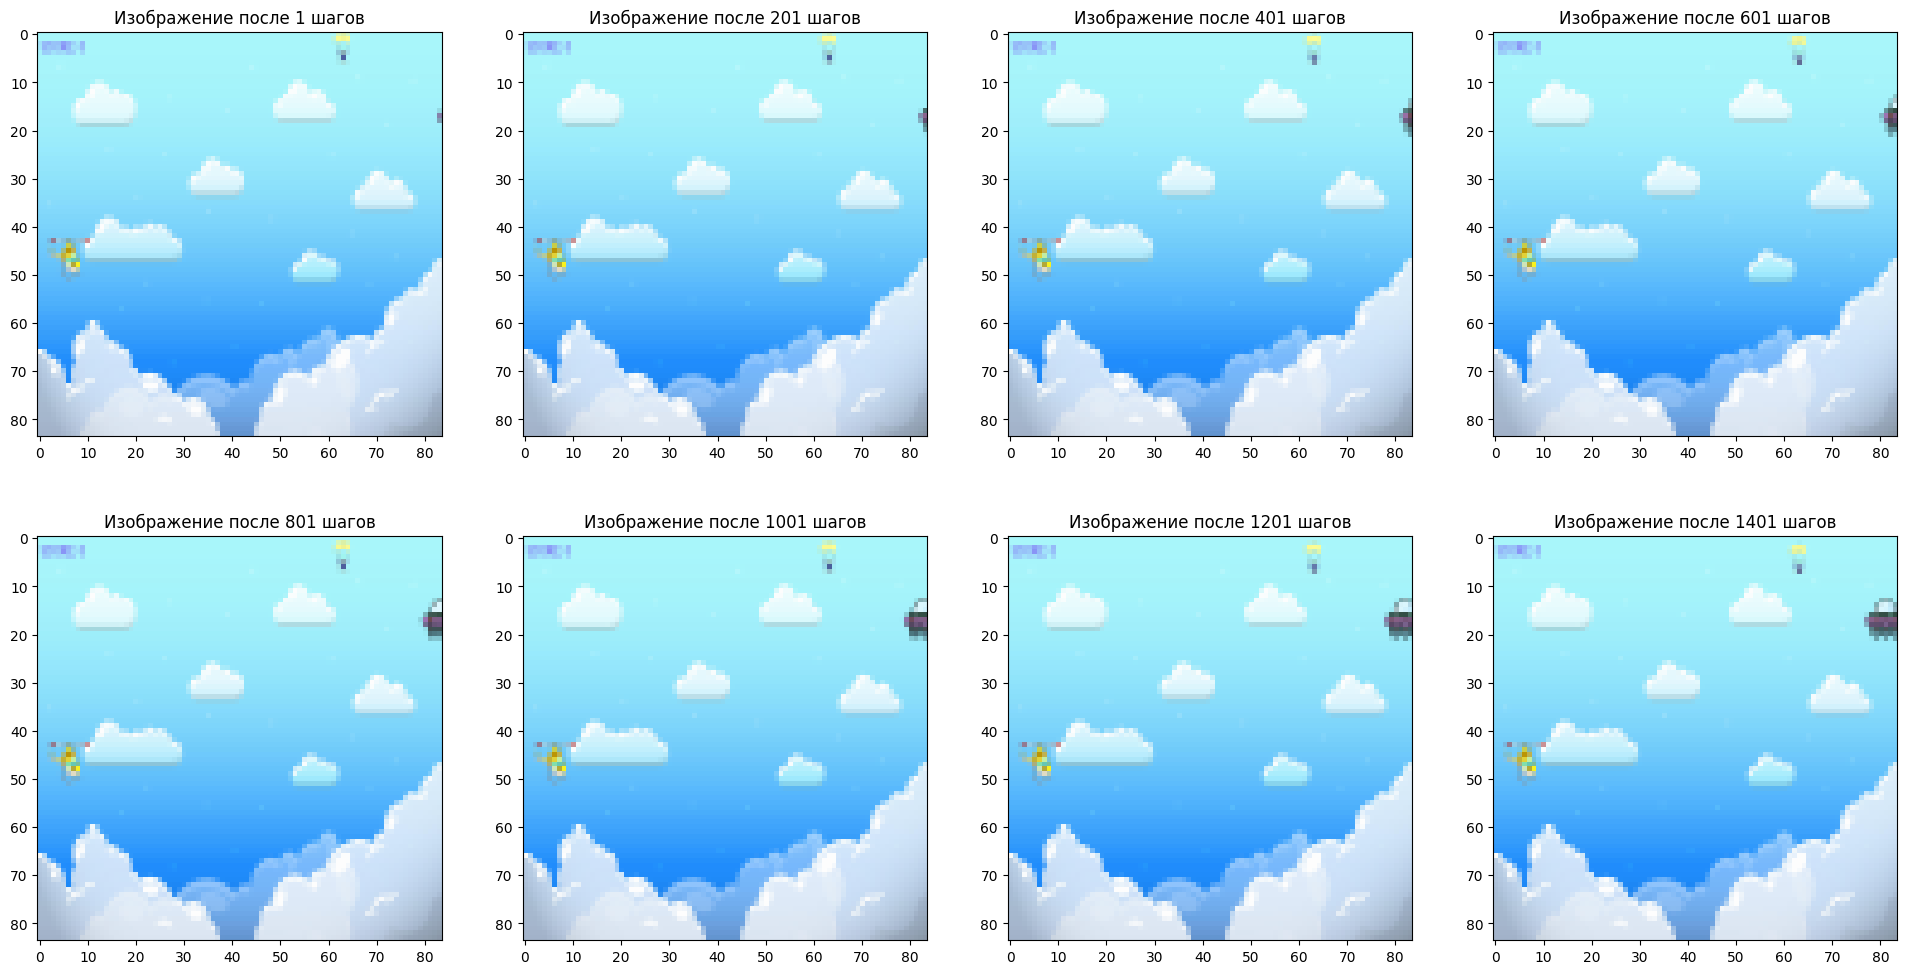

In [21]:
env = HeliRescueEnv(assets_dir='.', render_mode='rgb_array', obs_size=(84, 84))
obs, info = env.reset(seed=42)
print(f"Observation shape: {obs.shape}")
print(f"Observation dtype: {obs.dtype}")
print(f"Info: {info}")
print(f"Action space: {env.action_space}")
print(f"Observation space: {env.observation_space}")

fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()
for i, j in enumerate(range(1, 200*8+1, 200)):
    obs, _, _, _, _ = env.step(0) 

    axes[i].imshow(obs)
    axes[i].set_title(f"Изображение после {j} шагов")
plt.show()

env.close()

In [24]:
# Случайный агент
env = HeliRescueEnv(
    assets_dir=".",
    render_mode="human",   
    obs_size=(84, 84)
)

obs, info = env.reset(seed=42)

done = False
truncated = False

while not (done or truncated):
    action = env.action_space.sample() 
    obs, reward, done, truncated, info = env.step(action)

env.close()